# Detaillierte Auswertung der LH Allee

- Welche Verkehrsströme liegen in 2019- 2024 vor
- Welche Emissionsfaktoren werden angewendet?
- Welcher share zwischen den Verkehrsklassen wird angewendet?
- Welche Emissionen auf Basis der Detektordaten?

Road Links 80609 (MR), 52804341, 52804339 (Seitenstraßen)<br>
Zählstellen: 4013; MQ401301 (Nord), MQ401302 (Süd)


In [1]:
import sys
import os
os.environ['USE_PYGEOS'] = '0'

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from datetime import datetime, time

import seaborn as sns

# import custom modules
sys.path.append('../../utils')
import data_paths
from traffic_counts import TrafficCounts
import excel_calendar
from hbefa_hot_emissions import HbefaHotEmissions
from hot_emission_process import process_daily_emissions, process_hourly_emissions


In [2]:
hbefa = HbefaHotEmissions()

Loaded emission factors from /Users/daniel_tum/Documents/code/drive-inventory/data/restricted_input/hbefa/EFA_HOT_ts_hbefa.txt
Loaded emission factors from /Users/daniel_tum/Documents/code/drive-inventory/data/restricted_input/hbefa/EFA_HOT_aggregated_hbefa.txt


In [3]:
hbefa.ef_aggregated['EFA_weighted'][2018, 'Urban', 'PC', 'NO2']

0.09

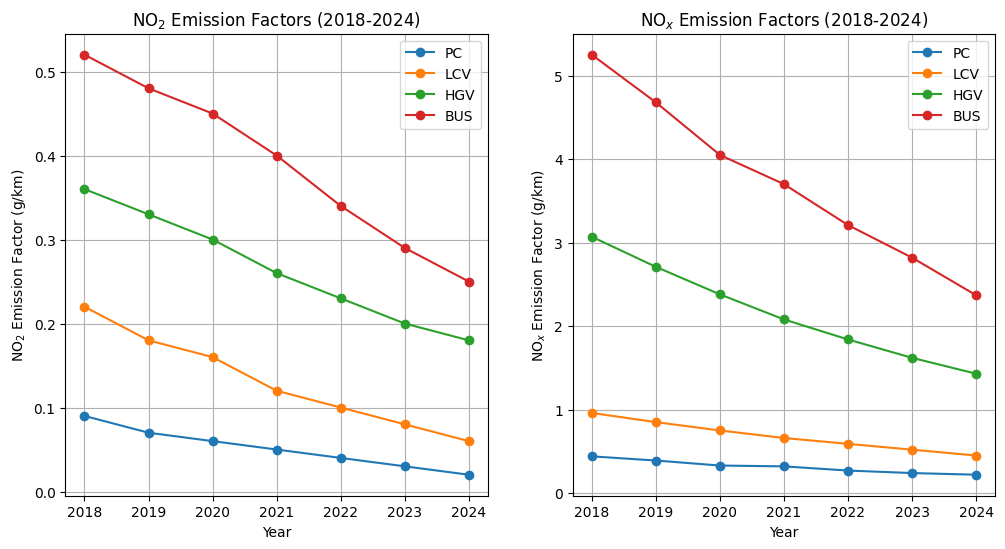

In [4]:
fig, ax = plt.subplots(1,2, figsize=(12,6))

years = range(2018,2025)
ax[0].plot(years, [hbefa.ef_aggregated['EFA_weighted'][year, 'Urban', 'PC', 'NO2'] for year in years], marker='o', label = 'PC')
ax[0].plot(years, [hbefa.ef_aggregated['EFA_weighted'][year, 'Urban', 'LCV', 'NO2'] for year in years], marker='o', label = 'LCV')
ax[0].plot(years, [hbefa.ef_aggregated['EFA_weighted'][year, 'Urban', 'HGV', 'NO2'] for year in years], marker='o', label = 'HGV')
ax[0].plot(years, [hbefa.ef_aggregated['EFA_weighted'][year, 'Urban', 'BUS', 'NO2'] for year in years], marker='o', label = 'BUS')

ax[1].plot(years, [hbefa.ef_aggregated['EFA_weighted'][year, 'Urban', 'PC', 'NOx'] for year in years], marker='o', label = 'PC')
ax[1].plot(years, [hbefa.ef_aggregated['EFA_weighted'][year, 'Urban', 'LCV', 'NOx'] for year in years], marker='o', label = 'LCV')
ax[1].plot(years, [hbefa.ef_aggregated['EFA_weighted'][year, 'Urban', 'HGV', 'NOx'] for year in years], marker='o', label = 'HGV')
ax[1].plot(years, [hbefa.ef_aggregated['EFA_weighted'][year, 'Urban', 'BUS', 'NOx'] for year in years], marker='o', label = 'BUS')

ax[0].set_title('NO$_2$ Emission Factors (2018-2024)')
ax[1].set_title('NO$_x$ Emission Factors (2018-2024)')

for a in ax:
    a.legend()
    a.set_xlabel('Year')
    a.grid(True)
    
ax[0].set_ylabel('NO$_2$ Emission Factor (g/km)')
ax[1].set_ylabel('NO$_x$ Emission Factor (g/km)')

plt.show()

# plot emission factors over speed

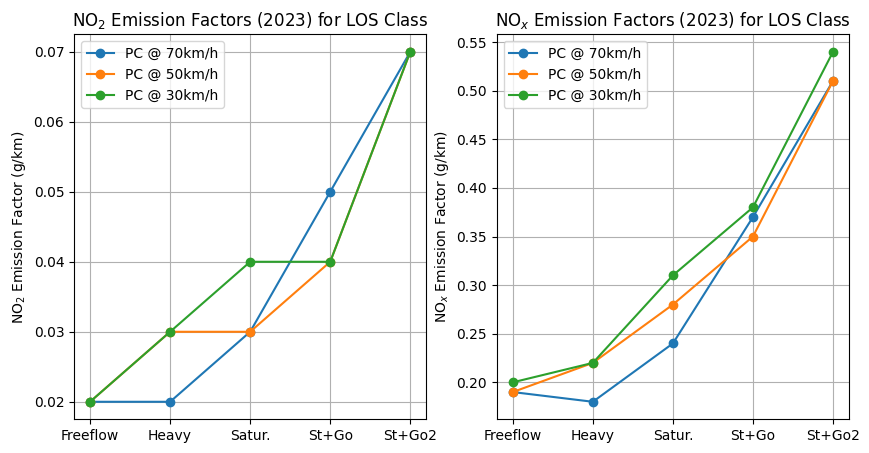

In [5]:
fig, ax = plt.subplots(1,2, figsize=(10,5))

year = 2023

los = ['Freeflow', 'Heavy', 'Satur.', 'St+Go', 'St+Go2']

pc_70 = [hbefa.ef_dict['EFA_weighted'][year, f'URB/Trunk-City/70/{l}', 'PC', '0%', 'NO2'] for l in los]
pc_50 = [hbefa.ef_dict['EFA_weighted'][year, f'URB/Trunk-City/50/{l}', 'PC', '0%', 'NO2'] for l in los]
pc_30 = [hbefa.ef_dict['EFA_weighted'][year, f'URB/Distr/50/{l}', 'PC', '0%', 'NO2'] for l in los]

ax[0].plot(los, pc_70, marker='o', label = 'PC @ 70km/h')
ax[0].plot(los, pc_50, marker='o', label = 'PC @ 50km/h')
ax[0].plot(los, pc_30, marker='o', label = 'PC @ 30km/h')

pc_70 = [hbefa.ef_dict['EFA_weighted'][year, f'URB/Trunk-City/70/{l}', 'PC', '0%', 'NOx'] for l in los]
pc_50 = [hbefa.ef_dict['EFA_weighted'][year, f'URB/Trunk-City/50/{l}', 'PC', '0%', 'NOx'] for l in los]
pc_30 = [hbefa.ef_dict['EFA_weighted'][year, f'URB/Distr/30/{l}', 'PC', '0%', 'NOx'] for l in los]

ax[1].plot(los, pc_70, marker='o', label = 'PC @ 70km/h')
ax[1].plot(los, pc_50, marker='o', label = 'PC @ 50km/h')
ax[1].plot(los, pc_30, marker='o', label = 'PC @ 30km/h')

ax[0].set_ylabel('NO$_2$ Emission Factor (g/km)')
ax[1].set_ylabel('NO$_x$ Emission Factor (g/km)')
ax[0].set_title(f'NO$_2$ Emission Factors ({year}) for LOS Class')
ax[1].set_title(f'NO$_x$ Emission Factors ({year}) for LOS Class')

for a in ax:
    a.legend()
    a.grid()

# Eval Traffic counts from 2019 until 2025

In [6]:
cnt = TrafficCounts()
cal = excel_calendar.Calendar()

cnt_data_filename = data_paths.COMBINED_COUNTING_DATA
cnt_data = pd.read_parquet(cnt_data_filename)

In [7]:
visum_filename = "visum_links.GPKG"
visum = gpd.read_file(data_paths.VISUM_FOLDER_PATH + visum_filename)
visum = visum[visum['road_link_id'].isin([52804341,80609,52804339])]

In [8]:
cnt_mr = cnt.annual_cycles['TrunkRoad/Primary-City'] * visum[visum['road_link_id']==80609]['dtv_SUM'].sum()
cnt_sr = cnt.annual_cycles['Distributor/Secondary'] * visum[visum['road_link_id']!=80609]['dtv_SUM'].sum()
daily_sum = cnt_mr + cnt_sr
df_daily = pd.DataFrame(daily_sum).reset_index()
df_daily['day_type'] = df_daily['date'].apply(lambda x: cal.get_day_type_combined(x))

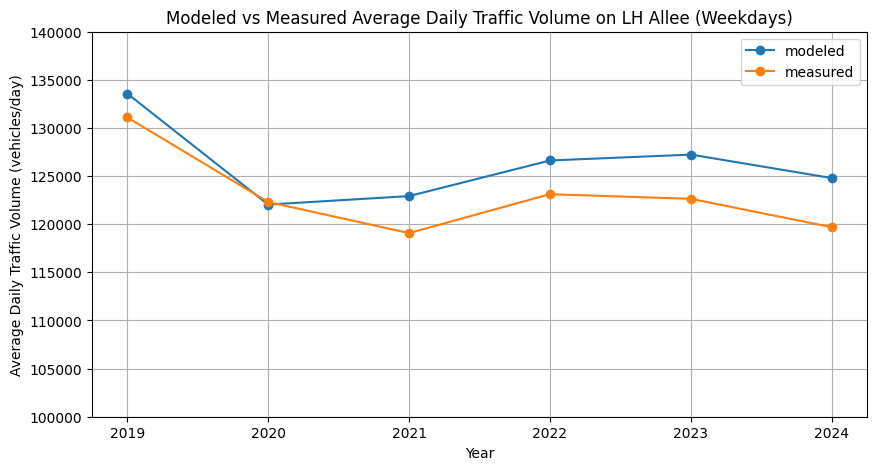

In [9]:
# plot modeled vs measured daily sums for average weekdays

plt.figure(figsize=(10,5))

modeled = df_daily[df_daily['day_type']==0].set_index('date').resample('1YE')['daily_value'].mean()
measured = cnt_data[(cnt_data['road_link_id'].isin([52804341,80609,52804339])) &
         (cnt_data['vehicle_class'] == 'SUM') &
         (cnt_data['day_type']==0)].set_index('date').resample('1d').sum()['daily_value']
measured= measured[measured>40000].resample('1YE').mean()

yeas = modeled.index.year
plt.plot(yeas, modeled.values, marker='o', label='modeled')
plt.plot(yeas, measured.values, marker='o', label='measured')

plt.xlabel('Year')
plt.ylabel('Average Daily Traffic Volume (vehicles/day)')
plt.title('Modeled vs Measured Average Daily Traffic Volume on LH Allee (Weekdays)')
plt.legend()
plt.ylim(100000, 140000)
plt.grid(True)
plt.show()




### Einfache Rechnung

In [10]:
print(f'Daily traffic total in the VISUM model (2019): {visum['dtv_SUM'].sum():.0f} veh/day')

Daily traffic total in the VISUM model (2019): 133736 veh/day


In [11]:
# step 1: calculate total vehicles per year
veh_year = visum['dtv_SUM'] * 365 * 0.8

In [38]:
year = 2024

veh = 120000  # vehicles per day
veh_year = veh * 365 * 0.8  # vehicles per year

#vehicle shares
share_BUS = 0.005
share_SNF = 0.05
share_LCV = 0.1
share_PC = 1- (share_BUS + share_SNF + share_LCV)

# length of road link section
length_of_roadlinks = visum.geometry.length.mean() * 1e-3  # mean length of the four road links in km

no2 = (veh_year * (share_PC * hbefa.ef_aggregated['EFA_weighted'][year, 'Urban', 'PC', 'NO2'] +
                   share_LCV * hbefa.ef_aggregated['EFA_weighted'][year, 'Urban', 'LCV', 'NO2'] +
                   share_SNF * hbefa.ef_aggregated['EFA_weighted'][year, 'Urban', 'HGV', 'NO2'] +
                   share_BUS * hbefa.ef_aggregated['EFA_weighted'][year, 'Urban', 'BUS', 'NO2']))

nox = (veh_year * (share_PC * hbefa.ef_aggregated['EFA_weighted'][year, 'Urban', 'PC', 'NOx'] +
                   share_LCV * hbefa.ef_aggregated['EFA_weighted'][year, 'Urban', 'LCV', 'NOx'] +
                   share_SNF * hbefa.ef_aggregated['EFA_weighted'][year, 'Urban', 'HGV', 'NOx'] +
                   share_BUS * hbefa.ef_aggregated['EFA_weighted'][year, 'Urban', 'BUS', 'NOx']))

print(f"Estimated Annual NO2 Emissions on LH Allee: {no2*1e-6:.2f} t/km")
print(f"Estimated Annual NOx Emissions on LH Allee: {nox*1e-6:.2f} t/km")

print(f'\nAlong the investigated road link section ({length_of_roadlinks:.2f} km):')
print(f"Estimated Annual NO2 Emissions: {no2 * length_of_roadlinks * 1e-6:.2f} t")
print(f"Estimated Annual NOx Emissions: {nox * length_of_roadlinks * 1e-6:.2f} t")

Estimated Annual NO2 Emissions on LH Allee: 1.16 t/km
Estimated Annual NOx Emissions on LH Allee: 11.01 t/km

Along the investigated road link section (0.16 km):
Estimated Annual NO2 Emissions: 0.18 t
Estimated Annual NOx Emissions: 1.73 t


## Comparison with Inventory output

Note: Erlaubte Geschwindigkeit ist 70 km/h auf Mittleren Ring im Modell! 

In [13]:
inv = gpd.read_file(data_paths.INVENTORY_PATH + f'linesource_Munich_{year}_los_specific.gpkg')
inv_lh = inv[inv['road_link_id'].isin([52804341, 80609, 52804339])]

# exact calculation along the road links
total_emissions = inv_lh.iloc[:,17:-1].multiply(inv_lh.geometry.length * 1e-6, axis="index") #in kg

print(f'Sum of NO2: {total_emissions[['PC_NO2', 'LCV_NO2', 'HGV_NO2', 'BUS_NO2', 'MOT_NO2']].sum().sum():.2f} kg')
print(f'Sum of NOx: {total_emissions[['PC_NOx', 'LCV_NOx', 'HGV_NOx', 'BUS_NOx', 'MOT_NOx']].sum().sum():.2f} kg')

Sum of NO2: 180.05 kg
Sum of NOx: 1619.79 kg


# Data availability of Counting data on the MR

In [14]:
cnt_data_ext = cnt_data.melt(id_vars = ['date', 'road_link_id','road_type', 'vehicle_class'],
                     value_vars = [str(x) for x in range(0,24)])
cnt_data_ext = cnt_data_ext[(cnt_data_ext['road_link_id']==80609) & (cnt_data_ext['vehicle_class']=='SUM')]
cnt_data_ext['timestamp'] = cnt_data_ext.apply(lambda row: pd.Timestamp.combine(row['date'],
                                                                time(int(row['variable']))), axis =1)

(429528.0, 482112.0)

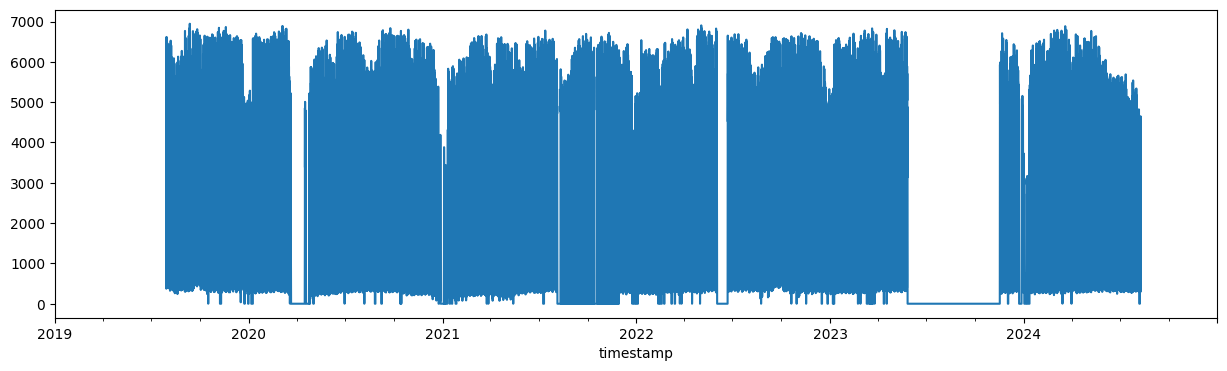

In [15]:
plt.figure(figsize=(15,4))
cnt_data_ext.set_index('timestamp').resample('1h')['value'].sum().plot()
plt.xlim(datetime(2019,1,1), datetime(2024,12,31))

# Speed dependent los class assignment

In [16]:
# METHOD 1: Use road type independent speed thresholds as proposed by Cox & Notter 2019
def get_speed_los(allowed_speed: float, 
                  actual_speed: float) -> str:
    """Returns traffic condition based on allowed and measured speed

    Args:
        allowed_speed (float): Signaled speed at the road link
        actual_speed (float): True measured speed at the road link

    Returns:
        str: Traffic condition based on the speed value
    """
    
    # source: Cox & Notter 2019
    speed_limit = [30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140]
    freeflow = [28.0, 34.0, 41.0, 54.0, 62.0, 72.0, 83.0, 92.0, 106.0, 117.0, 127.0, 135.0]
    heavy = [20.2, 25.3, 29.0, 37.9, 45.1, 52.2, 60.0, 66.3, 77.1, 87.1, 95.3, 108.6]
    saturated = [12.4, 15.5, 17.1, 19.8, 23.0, 25.5, 26.0, 26.0, 26.0, 26.0, 26.0, 26.0]
    stopandgo = [7.6, 8.7, 9.2, 9.2, 10.1, 10.5, 11.0, 11.0, 11.0, 11.0, 11.0, 11.0]
    v_thresholds = pd.DataFrame(index = speed_limit, 
                                data = {'Freeflow': freeflow,
                                        'Heavy': heavy,
                                        'Satur.': saturated,
                                        'St+Go': stopandgo})
    
    # convert allowed speed to closest speed in Hbefa
    speed_diff = np.abs((np.array(speed_limit) - allowed_speed))
    hbefa_speed = speed_limit[np.argmin(speed_diff)]
    
    # select speed thesholds depending on the allowed speed
    speed_thresholds = np.array(v_thresholds.loc[hbefa_speed])
    
    # select the LOS based on the actual speed
    for i, threshold in enumerate(speed_thresholds):
        if actual_speed >= threshold:
            return v_thresholds.columns[i]
    return 'St+Go2'

In [17]:
cnt_lhm = pd.read_parquet(data_paths.MST_COUNTING_PATH + 'preprocessed_lhm_counting_data_until2024.parquet')

In [ ]:
cnt_north = cnt_lhm[cnt_lhm['detector_id'].isin([4013011, 4013012, 4013013, 4013014])]
cnt_south = cnt_lhm[cnt_lhm['detector_id'].isin([4013021, 4013022, 4013023, 4013024])]

cnt_north = cnt_north.melt(id_vars = ['date', 'road_link_id', 'vehicle_class', 'metric'],
                     value_vars = [str(x) for x in range(0,24)])
cnt_north = cnt_north[cnt_north['value'] >5]

cnt_south = cnt_south.melt(id_vars = ['date', 'road_link_id', 'vehicle_class', 'metric'],
                     value_vars = [str(x) for x in range(0,24)])
cnt_south = cnt_south[cnt_south['value'] >5]

cnt_north_volume = cnt_north[cnt_north['metric']=='volume'].groupby(['date', 'variable', 'vehicle_class'])['value'].sum().reset_index()
cnt_north_speed= cnt_north[cnt_north['metric']=='speed'].groupby(['date', 'variable', 'vehicle_class'])['value'].mean().reset_index()

cnt_south_volume = cnt_south[cnt_south['metric']=='volume'].groupby(['date', 'variable', 'vehicle_class'])['value'].sum().reset_index()
cnt_south_speed= cnt_south[cnt_south['metric']=='speed'].groupby(['date', 'variable', 'vehicle_class'])['value'].mean().reset_index()

cnt_north_volume['timestamp'] = cnt_north_volume.apply(lambda row: pd.Timestamp.combine(row['date'],
                                                                time(int(row['variable']))), axis =1)
cnt_north_speed['timestamp'] = cnt_north_speed.apply(lambda row: pd.Timestamp.combine(row['date'],
                                                                time(int(row['variable']))), axis =1)
cnt_south_volume['timestamp'] = cnt_south_volume.apply(lambda row: pd.Timestamp.combine(row['date'],
                                                                time(int(row['variable']))), axis =1)
cnt_south_speed['timestamp'] = cnt_south_speed.apply(lambda row: pd.Timestamp.combine(row['date'],
                                                                time(int(row['variable']))), axis =1)

In [29]:
speed_south = cnt_south_speed[cnt_south_speed['vehicle_class'] == 'PC'].set_index('timestamp')['value']
speed_south.name = 'speed'
volume_south = cnt_south_volume[cnt_south_volume['vehicle_class'] == 'SUM'].set_index('timestamp')['value']
volume_south.name = 'volume'

speed_north = cnt_north_speed[cnt_north_speed['vehicle_class'] == 'PC'].set_index('timestamp')['value']
speed_north.name = 'speed'
volume_north = cnt_north_volume[cnt_north_volume['vehicle_class'] == 'SUM'].set_index('timestamp')['value']
volume_north.name = 'volume'

In [30]:
dfs = pd.concat([speed_south, volume_south], axis = 1)
dfs.sort_index(ascending=True, inplace=True)

dfn = pd.concat([speed_north, volume_north], axis = 1)
dfn.sort_index(ascending=True, inplace=True)


dfs.loc[:'2024-06-03','LOS'] = dfs.loc[:'2024-06-03'].apply(lambda row: get_speed_los(50, row['speed']), axis =1)
dfs.loc['2024-06-03':,'LOS'] = dfs.loc['2024-06-03':].apply(lambda row: get_speed_los(30, row['speed']), axis =1)
dfs.drop(dfs[dfs['speed']==0].index)

dfn.loc[:'2024-06-03','LOS'] = dfn.loc[:'2024-06-03'].apply(lambda row: get_speed_los(50, row['speed']), axis =1)
dfn.loc['2024-06-03':,'LOS'] = dfn.loc['2024-06-03':].apply(lambda row: get_speed_los(30, row['speed']), axis =1)
dfn.drop(dfn[dfn['speed']==0].index)


,speed,volume,LOS
timestamp,,,
2019-02-26 00:00:00,67.0,21.0,Freeflow
2019-02-26 01:00:00,66.0,7.0,Freeflow
2019-02-26 02:00:00,73.0,NaN,Freeflow
2019-02-26 03:00:00,59.0,6.0,Freeflow
2019-02-26 04:00:00,68.0,15.0,Freeflow
...,...,...,...
2024-12-31 19:00:00,36.0,432.0,Freeflow
2024-12-31 20:00:00,38.0,290.0,Freeflow
2024-12-31 21:00:00,38.0,227.0,Freeflow


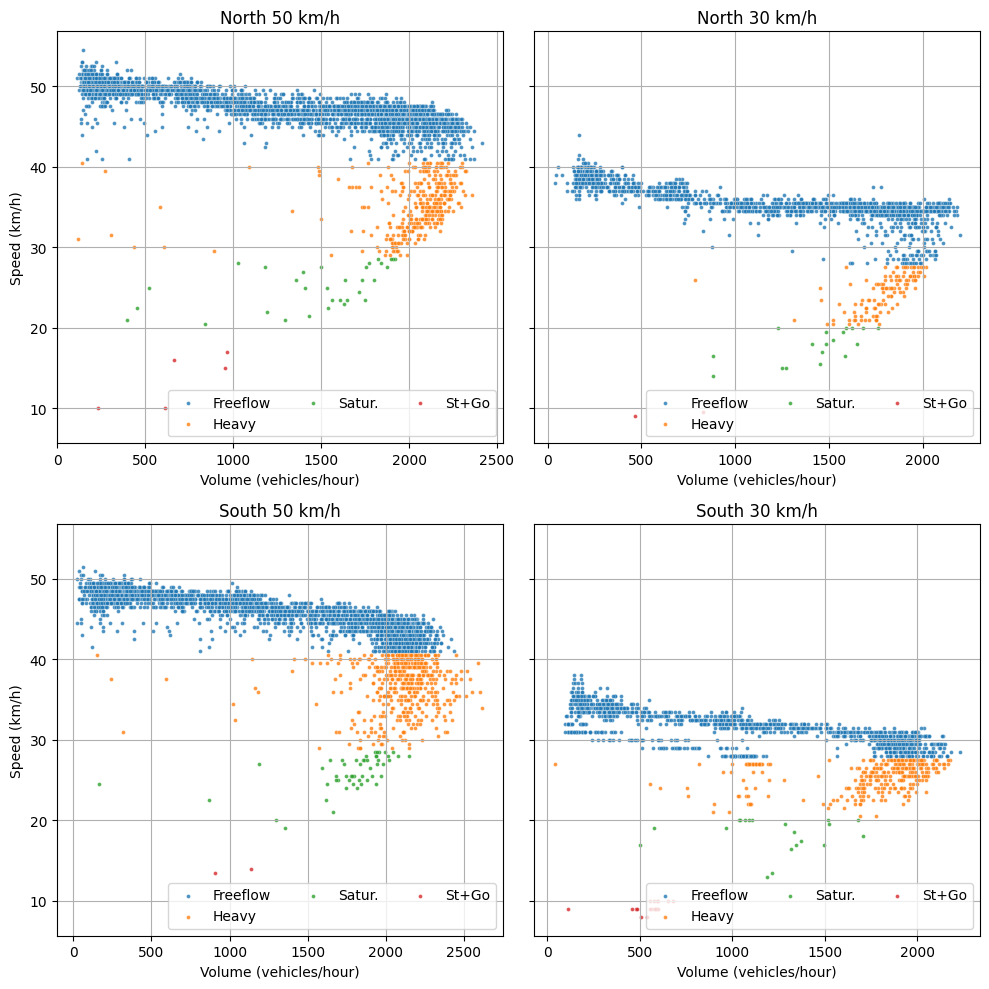

In [32]:
fig, ax = plt.subplots(2,2,figsize = (10,10), sharey = True, tight_layout = True)

for l in dfs['LOS'].unique():
    ax[0,0].set_title('North 50 km/h')
    sns.scatterplot(ax=ax[0,0], data=dfn[dfn['LOS']==l].loc['2024-01-01':'2024-05-30'],
                    x='volume', y='speed', label=l, alpha=0.8, s=8)
    
    ax[0,1].set_title('North 30 km/h')
    sns.scatterplot(ax=ax[0,1], data=dfn[dfn['LOS']==l].loc['2024-06-04':'2024-08-30'],
                    x='volume', y='speed', label=l, alpha=0.8, s=8)
    
    ax[1,0].set_title('South 50 km/h')
    sns.scatterplot(ax=ax[1,0], data=dfs[dfs['LOS']==l].loc['2024-01-01':'2024-05-30'],
                    x='volume', y='speed', label=l, alpha=0.8, s=8)
    
    ax[1,1].set_title('South 30 km/h')
    sns.scatterplot(ax=ax[1,1], data=dfs[dfs['LOS']==l].loc['2024-06-04':'2024-08-30'],
                    x='volume', y='speed', label=l, alpha=0.8, s=8)
    
    for a in ax.flatten():
        a.set_xlabel('Volume (vehicles/hour)')
        a.set_ylabel('Speed (km/h)')
        a.legend(loc ='lower right', ncol=3)
        a.grid(True)